In [1]:
import cv2
from models import Model
from hydra import initialize, compose
from omegaconf import OmegaConf
import matplotlib.pyplot as plt
import numpy as np
from models.utils import visualization as utils

with initialize(version_base=None, config_path="configs"):
    cfg = compose(config_name="inference")
    if cfg.model.name == 'yolo':
        cfg.dataset.names = [cls for cls in cfg.dataset.names if cls != '__background__']
        cfg.dataset.nc = len(cfg.dataset.names)

print(OmegaConf.to_yaml(cfg))

/Users/albertomarengo/Bitstrapped-Project/my_yolo/yol-venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


model:
  name: yolo
  image_size:
  - 512
  - 512
  - 3
  backbone_name: resnet34
  fpn_channels: 384
  returned_layers:
  - 1
  - 2
  - 3
  - 4
  train_backbone: true
  top_k_per_level: 1
  center_radius: 1.0
  allow_multi_level: true
  nms_threshold: 0.7
  score_threshold: 0.7
  max_detections: 10
  metadata:
    best_model_folder: trained_model
dataset:
  train: ../Dataset/train/Vehicle registration plate
  val: ../Dataset/validation/Vehicle registration plate
  nc: 1
  names:
  - Reg-plate
  metadata:
    workspace: alberto-marengo
    project: licence-plate-detection
    dataset: licence-plate-detection
    version: 1
    url: https://www.dropbox.com/s/k81ljpmzy3fgtx9/Dataset.zip?dl=1
experiment:
  train:
    debug: false
    use_wandb: true
    epochs: 200
    batch_size: 32
    seed: 42
    num_workers: 4



In [2]:
cfg.dataset.names

['Reg-plate']

In [3]:
model = Model(cfg, model_name="yolo_fancy_univers")
# model = Model(cfg, model_name="Detector_train")

/Users/albertomarengo/Bitstrapped-Project/my_yolo/yol-venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/albertomarengo/Bitstrapped-Project/my_yolo/yol-venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Freezing conv1.weight
Freezing bn1.weight
Freezing bn1.bias
Freezing layer1.0.conv1.weight
Freezing layer1.0.bn1.weight
Freezing layer1.0.bn1.bias
Freezing layer1.0.conv2.weight
Freezing layer1.0.bn2.weight
Freezing layer1.0.bn2.bias
Freezing layer1.1.conv1.weight
Freezing layer1.1.bn1.weight
Freezing layer1.1.bn1.bias
Freezing layer1.1.conv2.weight
Freezing layer1.1.bn2.weight
Freezing layer1.1.bn2.bias
Freezing layer1.2.conv1.weight
Freezing layer1.2.bn1.weight
Freezing layer1.2.bn1.bias
Freezing layer1.2.conv2.weight
Freezing layer1.2.bn2.weight
Freezing layer1.2.bn2.bias
Freezing fc.weight
Freezing fc.bias


In [4]:
print(model.wrapper.model)

YOLO(
  (backbone): DetBackbone(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          

In [5]:
nms_threshold = 0.4
score_threshold = 0.75
pred = model("samples/1f0e643b125f00ec.jpg", nms_threshold=nms_threshold, score_threshold=score_threshold)

In [6]:
def plot_predictions(prediction):
    # Define subplots
    fig, ax = plt.subplots(
        nrows=1,
        ncols=1,
        figsize=(10, 10),
    )
    # Plot Predictions.
    orig_image = utils.draw_bbox(
        prediction['image_array'],
        np.array(prediction['final_boxes'], dtype=np.int32),
        labels=pred['class_names'],
        color=(255, 0, 0),
        thickness=2,
    )


    ax.imshow(orig_image)
    ax.axis("off")

    plt.figtext(0.50, 0.9, "Predictions", fontsize=20, color="r", ha="center")

    plt.show(block=False)

    return fig

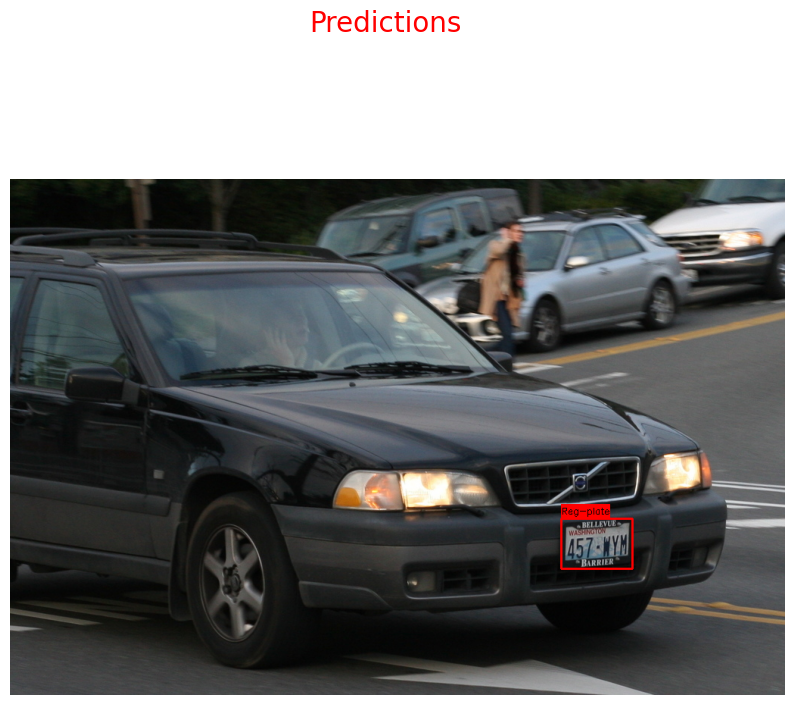

In [7]:
figure = plot_predictions(pred)

In [ ]:
model.evaluate(cfg.dataset.val.replace('..', 'dataset'))